In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Load and Explore Dataset

In [65]:
# Load the dataset
df = pd.read_csv("heart_disease_uci.csv")

# View first few rows
print(df.head())

df = df.drop(columns=["dataset"], errors="ignore")  # Safely drop if exists

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


Data Cleaning and Preprocessing

In [66]:
# Convert 'sex' to numeric with .loc to avoid SettingWithCopyWarning
df.loc[:, 'sex'] = df['sex'].map({'Male': 1, 'Female': 0})

# Drop rows where 'fbs' or 'exang' is missing
df = df.dropna(subset=['fbs', 'exang'])

# Convert booleans to integers
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=["cp", "restecg", "slope", "thal"])

# Rename target column if necessary
if 'num' in df.columns:
    df.rename(columns={"num": "target"}, inplace=True)

# Make target binary
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

# Drop non-numeric text columns
df = df.drop(columns=["dataset"], errors="ignore")

Data Visualization

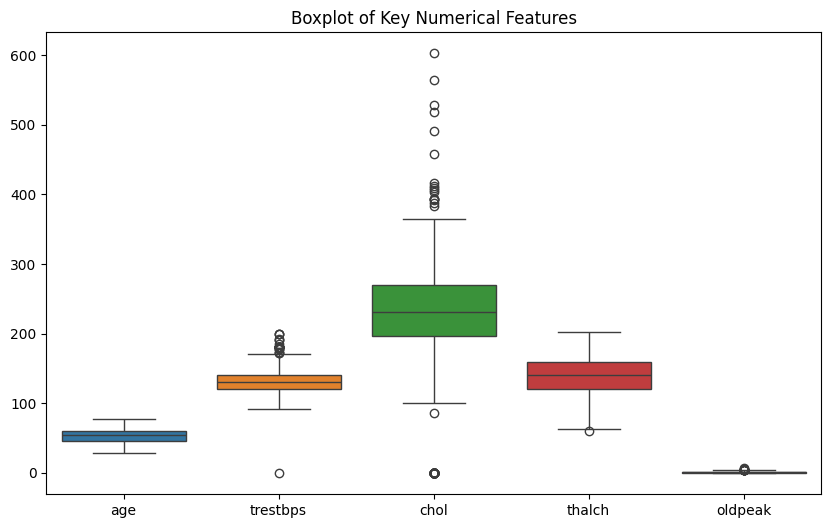

In [67]:
# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']])
plt.title("Boxplot of Key Numerical Features")
plt.show()

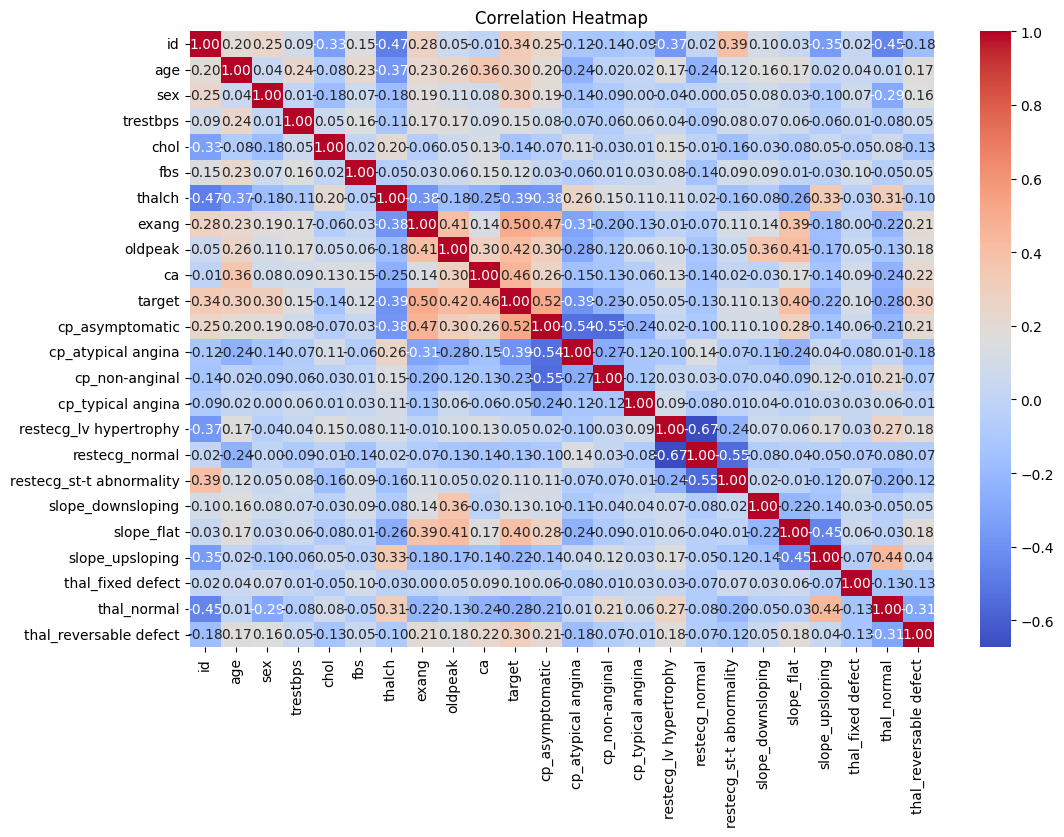

In [68]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

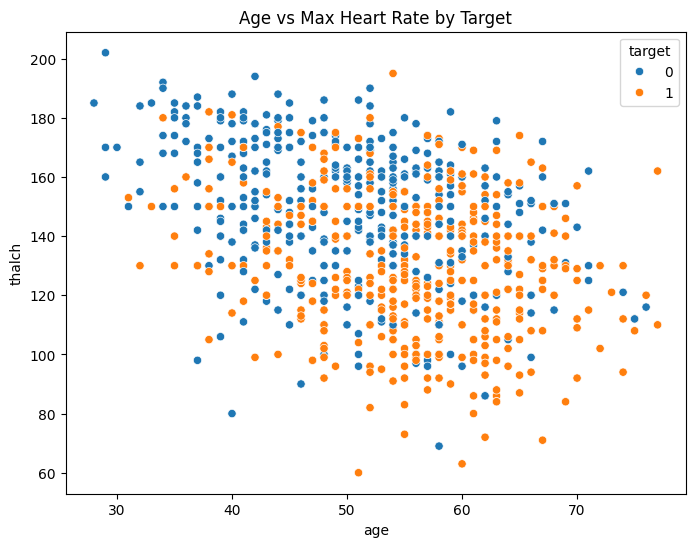

In [69]:
# Scatterplot: Age vs Max Heart Rate
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="thalch", hue="target")
plt.title("Age vs Max Heart Rate by Target")
plt.show()

Prepare Data for Modeling

In [70]:
# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

Decision Tree Classifier

In [71]:
# Train and predict
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8326180257510729
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       110
           1       0.84      0.84      0.84       123

    accuracy                           0.83       233
   macro avg       0.83      0.83      0.83       233
weighted avg       0.83      0.83      0.83       233



K-Nearest Neighbors (KNN) Classifier

In [72]:
# Feature-target split
X = df.drop("target", axis=1)
y = df["target"]

# Drop any remaining rows with missing values
df_cleaned = pd.concat([X, y], axis=1).dropna()
X = df_cleaned.drop("target", axis=1)
y = df_cleaned["target"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [76]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_report = classification_report(y_test, y_pred_knn)
knn_cm = confusion_matrix(y_test, y_pred_knn)

# Train and predict
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8351648351648352
              precision    recall  f1-score   support

           0       0.86      0.85      0.85        52
           1       0.80      0.82      0.81        39

    accuracy                           0.84        91
   macro avg       0.83      0.83      0.83        91
weighted avg       0.84      0.84      0.84        91



Confusion Matrix Comparison

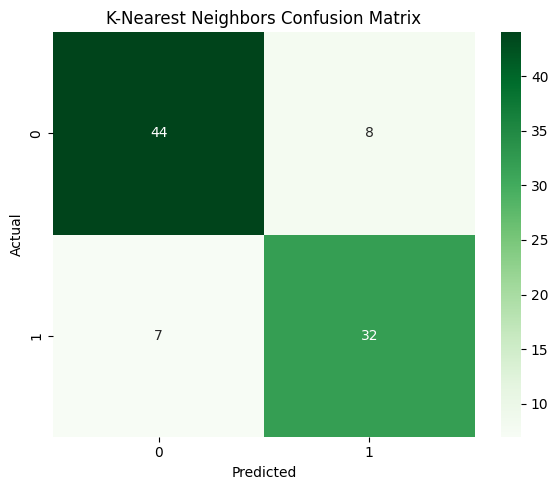

In [77]:
# Confusion matrices

plt.figure(figsize=(6, 5))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens")
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()